In [1]:
import distutils.util
import os
import subprocess

# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

import mediapy as media
import matplotlib.pyplot as plt

# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from brax.training.agents.sac import train as sac_train
from brax.training.agents.sac import networks as sac_networks
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry

registry.locomotion.ALL_ENVS

('ApolloJoystickFlatTerrain',
 'BarkourJoystick',
 'BerkeleyHumanoidJoystickFlatTerrain',
 'BerkeleyHumanoidJoystickRoughTerrain',
 'G1JoystickFlatTerrain',
 'G1JoystickRoughTerrain',
 'Go1JoystickFlatTerrain',
 'Go1JoystickRoughTerrain',
 'Go1Getup',
 'Go1Handstand',
 'Go1Footstand',
 'H1InplaceGaitTracking',
 'H1JoystickGaitTracking',
 'Op3Joystick',
 'SpotFlatTerrainJoystick',
 'SpotGetup',
 'SpotJoystickGaitTracking',
 'T1JoystickFlatTerrain',
 'T1JoystickRoughTerrain',
 'PupperJoystickFlatTerrain',
 'PupperJoystickSacFlatTerrain',
 'PupperJoystickWithGun',
 'PupperGetup')

In [2]:
env_name = 'PupperGetup'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)
env_cfg

Kd: 0.01
Kp: 0.19
action_repeat: 1
action_scale: 0.5
ctrl_dt: 0.02
drop_from_height_prob: 0.6
energy_termination_threshold: .inf
episode_length: 300
noise_config:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.03
    joint_vel: 1.5
reward_config:
  scales:
    action_rate: -0.001
    dof_acc: -2.5e-07
    dof_pos_limits: -0.1
    dof_vel: -0.1
    orientation: 1.0
    posture: 1.0
    stand_still: 1.0
    torques: -1.0e-05
    torso_height: 1.0
settle_time: 0.5
sim_dt: 0.004
soft_joint_pos_limit_factor: 0.95

In [3]:
from mujoco_playground.config import locomotion_params
ppo_params = locomotion_params.brax_ppo_config(env_name)
ppo_params

action_repeat: 1
batch_size: 256
discounting: 0.97
entropy_cost: 0.01
episode_length: 300
learning_rate: 0.0003
max_grad_norm: 1.0
network_factory:
  policy_hidden_layer_sizes: &id001 !!python/tuple
  - 512
  - 256
  - 128
  policy_obs_key: state
  value_hidden_layer_sizes: *id001
  value_obs_key: privileged_state
normalize_observations: true
num_envs: 8192
num_evals: 20
num_minibatches: 32
num_timesteps: 100000000
num_updates_per_batch: 4
reward_scaling: 1.0
unroll_length: 20

In [4]:
registry.get_domain_randomizer(env_name)

<function mujoco_playground._src.locomotion.pupper.randomize.domain_randomize(model: mujoco.mjx._src.types.Model, rng: jax.Array)>

In [5]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]

def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())



import pickle

ckpt_path = epath.Path("checkpoints") / env_name
ckpt_path.mkdir(parents=True, exist_ok=True)

def save_policy_params(current_step: int, make_policy_fn: Any, params: Any):
  """
  A callback function to manually save parameters as a .pkl file.
  It uses the `ckpt_path` variable from the outer scope.
  """
  step_path = ckpt_path / str(current_step)
  step_path.mkdir(parents=True, exist_ok=True) 
  pkl_file_path = step_path / "params.pkl"
  
  try:
    with open(pkl_file_path, 'wb') as f:
      pickle.dump(params, f)
    print(f"--- Custom save: .pkl for {env_name} saved to {pkl_file_path} ---")
  except Exception as e:
    print(f"ERROR during custom .pkl save: {e}")



randomizer = registry.get_domain_randomizer(env_name)
ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    randomization_fn=randomizer,
    progress_fn=progress,
    policy_params_fn=save_policy_params
)

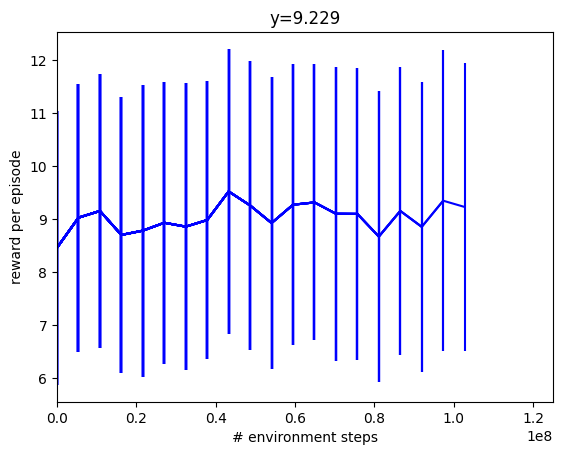

time to jit: 0:02:08.786815
time to train: 0:04:59.881925


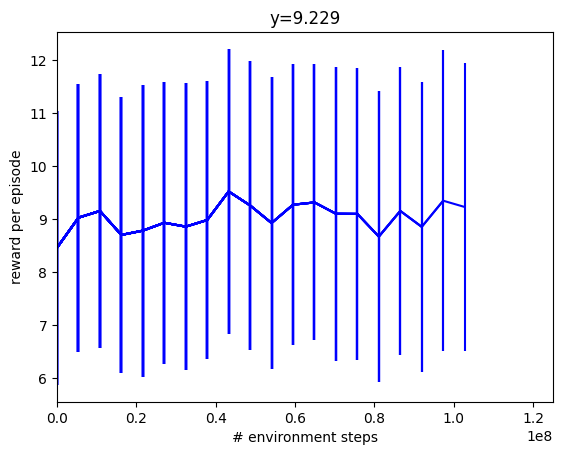

In [6]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    eval_env=registry.load(env_name, config=env_cfg),
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [7]:
# ===================================================================
#      為 Getup 環境設計的 Rollout and Render 腳本
# ===================================================================

# --- 步驟 1: 確保加載的是 Getup 環境和對應的模型參數 ---
# (這一步假設您在之前的單元格中已經完成了)
# env_name = 'PupperGetup'
# env = registry.load(env_name)
# env_cfg = registry.get_default_config(env_name)
# make_inference_fn, params, _ = train_fn(...) # 確保 train_fn 使用了 Getup 的配置

# --- 步驟 2: 準備和運行模擬 ---

# 創建一個 JIT 編譯好的、確定性的推理函數
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

# JIT 編譯環境的 reset 和 step 函數以加速
# 注意：這裡我們使用 eval_env，它可能是一個被包裝過的環境
# 為了穩定，最好直接使用一個新的、原始的 Getup 環境來渲染
eval_env_getup = registry.load(env_name, config=env_cfg)
jit_reset = jax.jit(eval_env_getup.reset)
jit_step = jax.jit(eval_env_getup.step)

rng = jax.random.PRNGKey(0)
# 重置環境，Getup 環境的 reset 會讓機器人處於摔倒姿態
state = jit_reset(rng)

# 初始化記錄列表
rollout = [state]
print("Starting rollout for Getup task...")

# 執行一個完整的 episode
for i in range(env_cfg.episode_length):
  # 獲取隨機數 key，即使不用，也要分割以保持狀態更新
  act_rng, rng = jax.random.split(rng)
  
  # 【關鍵修改 1】: 推理函數的輸入不再需要 command
  # Getup 環境的觀測空間不包含 command，所以 state.obs 的結構不同
  # 我們需要確保 jit_inference_fn 能處理這種 obs
  # Brax 的 make_inference_fn 通常能自動處理 Pytree，所以這裡可能不需要修改
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  
  # 【關鍵修改 2】: 環境的 step 也不再需要更新 command
  state = jit_step(state, ctrl)
  
  rollout.append(state)

  # 如果 episode 結束（例如，機器人摔倒或達到時間限制），就提前終止
  if state.done:
    print(f"Episode finished early at step {i+1}.")
    break

print("Rollout finished.")

# --- 步驟 3: 渲染影片 ---
render_every = 2
# 使用 eval_env_getup 的 dt 來計算 fps
fps = 1.0 / eval_env_getup.dt / render_every 
print(f"Rendering video at {fps:.2f} FPS...")

traj = rollout[::render_every]

# 創建一個乾淨的場景選項
scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True # 顯示接觸點

# 【關鍵修改 3】: 渲染時不再需要 modify_scene_fns
# 因為 Getup 任務沒有 joystick command 需要可視化
frames = eval_env_getup.render(
    trajectory=traj,
    camera="track",
    scene_option=scene_option,
    width=640,
    height=480,
)

media.show_video(frames, fps=fps, loop=False)
print("Video rendering complete.")

2025-07-16 11:10:14.980381: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Starting rollout for Getup task...
Rollout finished.
Rendering video at 25.00 FPS...


100%|██████████| 151/151 [00:02<00:00, 53.70it/s]


This browser does not support the video tag.


Video rendering complete.
